# Connecting to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install dependencies

In [ ]:
!pip install soundfile

# Import libraries

In [ ]:
import os
import glob
import csv
import random

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
from collections import Counter

import torchaudio

# Check for GPU

In [ ]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# Configurations

In [ ]:
SAMPLE_RATE = 16000

FRAME_LENGTH = 2048
HOP_LENGTH = 512

N_FFT = 1024
MEL_HOP = 256
N_MELS = 128

BATCH_SIZE = 32
EPOCHS = 100

NUM_CLASSES = 3

# Distance Bin and Get distance function

In [ ]:
DISTANCE_BINS = {
    0: (0, 2.5),
    1: (2.5, 5.0),
    2: (5.0, 10.0)
}

def get_distance_class(distance):

    for cls, (low, high) in DISTANCE_BINS.items():

        if low <= distance < high:
            return cls

    return 2

# Sound Distance Dataset Class

In [ ]:
class SoundDistanceDataset(Dataset):

    def __init__(self, csv_files, mic_dir, augment=False):

        self.data = []
        self.augment = augment

        # Use Spectrogram to get complex output
        self.spectrogram_transform = torchaudio.transforms.Spectrogram(
            n_fft=N_FFT,
            hop_length=MEL_HOP,
            return_complex=True
        )

        self.mel_scale_transform = torchaudio.transforms.MelScale(
            n_mels=N_MELS,
            sample_rate=SAMPLE_RATE,
            n_stft=N_FFT // 2 + 1
        )

        self.db_transform = torchaudio.transforms.AmplitudeToDB()

        self.freq_mask = torchaudio.transforms.FrequencyMasking(
            freq_mask_param=12
        )

        self.time_mask = torchaudio.transforms.TimeMasking(
            time_mask_param=12
        )

        print(f"Building dataset from {len(csv_files)} CSV files")

        for csv_file in csv_files:

            base = os.path.basename(csv_file).replace(".csv", ".wav")

            wav_file = os.path.join(mic_dir, base)

            if not os.path.exists(wav_file):
                continue

            audio, sr = sf.read(wav_file)

            if audio.ndim == 1:
                audio = audio[:, np.newaxis]

            if sr != SAMPLE_RATE:

                audio_t = torch.tensor(
                    audio.T,
                    dtype=torch.float32
                )

                audio_t = torchaudio.functional.resample(
                    audio_t,
                    sr,
                    SAMPLE_RATE
                )

                audio = audio_t.T.numpy()

            labels = {}

            with open(csv_file) as f:

                reader = csv.reader(f)

                for row in reader:

                    frame_idx = int(row[0])

                    distance = float(row[5])

                    labels[frame_idx] = distance

            matched = 0

            for start in range(
                0,
                len(audio) - FRAME_LENGTH,
                HOP_LENGTH
            ):

                frame_idx = start // HOP_LENGTH

                if frame_idx in labels:

                    frame_audio = audio[
                        start:start + FRAME_LENGTH
                    ]

                    frame_audio = frame_audio.T.astype(np.float32)

                    self.data.append(
                        (
                            frame_audio,
                            labels[frame_idx]
                        )
                    )

                    matched += 1

            print(
                f"{os.path.basename(csv_file)} "
                f"-> {matched} labeled frames"
            )

        print(f"Total examples: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        waveform, distance = self.data[idx]

        waveform = torch.tensor(
            waveform,
            dtype=torch.float32
        )

        mel_magnitude_specs_augmented = []
        ipd_mel_specs = []

        if waveform.shape[0] < 2:
            raise ValueError("IPD requires at least 2 channels")

        complex_spectrograms = []

        for ch in waveform:
            spec_complex = self.spectrogram_transform(ch)
            complex_spectrograms.append(spec_complex)

            mel_mag = self.mel_scale_transform(spec_complex.abs())
            mel_mag = self.db_transform(mel_mag)
            mel_mag = (mel_mag - mel_mag.mean()) / (mel_mag.std() + 1e-6)

            if self.augment:
                if torch.rand(1).item() < 0.5:
                    mel_mag = self.freq_mask(mel_mag)
                if torch.rand(1).item() < 0.5:
                    mel_mag = self.time_mask(mel_mag)

            mel_magnitude_specs_augmented.append(mel_mag)

        # Calculate IPD features
        # Using mic0 as reference for IPD calculation
        phase_mic0 = torch.angle(complex_spectrograms[0])

        if waveform.shape[0] > 1:
            phase_mic1 = torch.angle(complex_spectrograms[1])
            ipd_01 = phase_mic0 - phase_mic1
            ipd_01 = torch.atan2(torch.sin(ipd_01), torch.cos(ipd_01))
            ipd_mel_specs.append(self.mel_scale_transform(ipd_01))

        if waveform.shape[0] > 2:
            phase_mic2 = torch.angle(complex_spectrograms[2])
            ipd_02 = phase_mic0 - phase_mic2
            ipd_02 = torch.atan2(torch.sin(ipd_02), torch.cos(ipd_02))
            ipd_mel_specs.append(self.mel_scale_transform(ipd_02))

        if waveform.shape[0] > 3:
            phase_mic3 = torch.angle(complex_spectrograms[3])
            ipd_03 = phase_mic0 - phase_mic3
            ipd_03 = torch.atan2(torch.sin(ipd_03), torch.cos(ipd_03))
            ipd_mel_specs.append(self.mel_scale_transform(ipd_03))

        # Normalize IPD Mel features
        for i in range(len(ipd_mel_specs)):
            ipd_mel_specs[i] = (ipd_mel_specs[i] - ipd_mel_specs[i].mean()) / (ipd_mel_specs[i].std() + 1e-6)

        # Concatenate augmented Mel-magnitude spectrograms and normalized IPD Mel spectrograms
        mel_specs = torch.stack(mel_magnitude_specs_augmented + ipd_mel_specs)

        return mel_specs, torch.tensor(distance, dtype=torch.float32)

# Neural Network Model Class

In [ ]:
class SpectrogramCNN(nn.Module):

    def __init__(self, n_channels=7, num_classes=3):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(n_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

# Calculate Class Weights to balance when training

In [ ]:
def calculate_class_weights(dataset):
    # Calculate counts for each binned distance class in the dataset
    class_counts = Counter([get_distance_class(item[1]) for item in dataset.data])
    total_samples = sum(class_counts.values())
    num_classes = len(DISTANCE_BINS)

    weights = []
    for cls in sorted(DISTANCE_BINS.keys()):
        count = class_counts.get(cls, 0)
        if count > 0:
            weights.append(total_samples / (count * num_classes))
        else:
            # Assign a reasonable weight if a class is entirely missing (e.g., 1.0 or max_weight)
            weights.append(1.0)

    print(f"Calculated class weights: {weights}")
    return torch.tensor(weights, dtype=torch.float32)

# Train model function

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    train_dataset,
    device,
    patience=10
):

    class_weights = calculate_class_weights(
        train_dataset
    ).to(device)

    criterion = nn.MSELoss(reduction='none')
    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.0003,
        weight_decay=1e-3
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_val_acc = 0.0

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(EPOCHS):

        # TRAIN
        model.train()

        current_train_loss = 0
        correct = 0
        total = 0

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device).unsqueeze(1)

            optimizer.zero_grad()

            out = model(x)

            true_classes_batch = torch.tensor(
                [get_distance_class(t.item()) for t in y.squeeze()],
                device=device
            )
            sample_weights_batch = class_weights[true_classes_batch].unsqueeze(1)

            loss = criterion(out, y)
            weighted_loss = (loss * sample_weights_batch).mean()

            weighted_loss.backward()

            optimizer.step()

            current_train_loss += weighted_loss.item()

            pred_classes = torch.tensor([get_distance_class(p.item()) for p in out.squeeze()], device=device)
            true_classes = torch.tensor([get_distance_class(t.item()) for t in y.squeeze()], device=device)

            total += y.size(0)
            correct += (pred_classes == true_classes).sum().item()

        epoch_train_loss = current_train_loss / len(train_loader)
        epoch_train_acc = 100 * correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # VALIDATION (Validation loss remains unweighted for true performance assessment)
        model.eval()

        current_val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(device)
                y = y.to(device).unsqueeze(1) # Reshape target for regression: (batch_size, 1)

                out = model(x)

                loss = nn.MSELoss()(out, y) # Use standard MSE for validation loss

                current_val_loss += loss.item()

                # For 'accuracy' evaluation in regression, convert predictions and targets to classes
                pred_classes = torch.tensor([get_distance_class(p.item()) for p in out.squeeze()], device=device)
                true_classes = torch.tensor([get_distance_class(t.item()) for t in y.squeeze()], device=device)

                total += y.size(0)
                correct += (pred_classes == true_classes).sum().item()

        epoch_val_loss = current_val_loss / len(val_loader)
        epoch_val_acc = 100 * correct / total
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        scheduler.step(epoch_val_loss)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Acc {epoch_train_acc:.2f}% | "
            f"Val Acc {epoch_val_acc:.2f}% | "
            f"Val Loss {epoch_val_loss:.4f}"
        )

        # Early Stopping Logic
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            # Save model when validation loss improves
            torch.save(
                model.state_dict(),
                "/content/drive/MyDrive/best_spectrogram_model.pth"
            )
            print("Saved best model (based on validation loss)")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {patience} epochs without improvement.")
                break

        # Although we save based on val_loss, we still track best_val_acc for reporting
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc

    return train_losses, val_losses, train_accs, val_accs

# Directory for dataset

In [ ]:
base_dir = "/content/drive/MyDrive/sonarretina/dcase/zenodo_upload"

meta_dir = os.path.join(base_dir, "meta_data")
mic_dir = os.path.join(base_dir, "mic_data")

# Find all csv files

In [ ]:
all_csv_files = glob.glob(
    os.path.join(
        meta_dir,
        "*.csv"
    )
)

print(f"Total available CSV files: {len(all_csv_files)}")

Total available CSV files: 1200


# Random distribute data for every fold

70% Training
20% Testing
10% Validation

In [ ]:
# Shuffle the files for random splitting
random.seed(42)
random.shuffle(all_csv_files)

# Define split percentages
train_split = 0.7
val_split = 0.1
test_split = 0.2

# Calculate split indices
total_files = len(all_csv_files)
train_idx = int(total_files * train_split)
val_idx = int(total_files * (train_split + val_split))

# Split the files
train_files = all_csv_files[:train_idx]
val_files = all_csv_files[train_idx:val_idx]
test_files = all_csv_files[val_idx:]

print(f"Train files: {len(train_files)}")
print(f"Validation files: {len(val_files)}")
print(f"Test files: {len(test_files)}")

Train files: 840
Validation files: 119
Test files: 241


# Label the data for every audio frame

In [ ]:
train_dataset = SoundDistanceDataset(
    train_files,
    mic_dir,
    augment=True
)

val_dataset = SoundDistanceDataset(
    val_files,
    mic_dir,
    augment=False
)

test_dataset = SoundDistanceDataset(
    test_files,
    mic_dir,
    augment=False
)

Building dataset from 840 CSV files


/usr/local/lib/python3.12/dist-packages/torchaudio/transforms/_transforms.py:95: UserWarning: `return_complex` argument is now deprecated and is not effective.`torchaudio.transforms.Spectrogram(power=None)` always returns a tensor with complex dtype. Please remove the argument in the function call.
  warnings.warn(


fold1_room1_mix109.csv -> 397 labeled frames
fold1_room6_mix104.csv -> 370 labeled frames
fold2_room3_mix071.csv -> 391 labeled frames
fold2_room3_mix013.csv -> 393 labeled frames
fold1_room2_mix042.csv -> 392 labeled frames
fold1_room1_mix065.csv -> 371 labeled frames
fold1_room3_mix100.csv -> 381 labeled frames
fold2_room3_mix045.csv -> 384 labeled frames
fold14_room1_mix139.csv -> 378 labeled frames
fold1_room5_mix043.csv -> 395 labeled frames
fold1_room2_mix095.csv -> 376 labeled frames
fold2_room1_mix075.csv -> 396 labeled frames
fold1_room4_mix080.csv -> 386 labeled frames
fold1_room3_mix019.csv -> 392 labeled frames
fold2_room2_mix049.csv -> 366 labeled frames
fold1_room6_mix129.csv -> 397 labeled frames
fold1_room3_mix086.csv -> 388 labeled frames
fold1_room5_mix061.csv -> 390 labeled frames
fold1_room1_mix131.csv -> 383 labeled frames
fold1_room5_mix018.csv -> 395 labeled frames
fold1_room5_mix103.csv -> 390 labeled frames
fold1_room4_mix138.csv -> 390 labeled frames
fold1_roo

In [ ]:
from torch.utils.data import WeightedRandomSampler

# Calculate sample weights for weighted random sampling

def get_sample_weights(dataset):
    # Fix: Removed .item() as item[1] is already a Python float
    class_counts = Counter([get_distance_class(item[1]) for item in dataset.data])
    total_samples = len(dataset)
    num_classes = len(DISTANCE_BINS)

    # Calculate inverse frequency weights for each class
    weights_per_class = {
        cls: total_samples / (class_counts[cls] * num_classes)
        for cls in DISTANCE_BINS.keys()
    }

    # Assign a weight to each sample based on its class
    sample_weights = []
    for _, distance in dataset.data:
        cls = get_distance_class(distance)
        sample_weights.append(weights_per_class[cls])

    return torch.tensor(sample_weights, dtype=torch.float32)


# Get weights for the training dataset
train_sample_weights = get_sample_weights(train_dataset)

# Create a WeightedRandomSampler
train_sampler = WeightedRandomSampler(
    train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True # Samples are drawn with replacement
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler, # Use the weighted sampler
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

### Check Class Distribution in Datasets

Let's analyze the distribution of the distance classes in our training, validation, and test datasets to identify any potential class imbalance.

In [ ]:
# def get_class_distribution(dataset):
#     classes = []
#     for _, distance in dataset:
#         classes.append(get_distance_class(distance.item()))
#     return Counter(classes)

# print("Train Dataset Class Distribution:")
# train_dist = get_class_distribution(train_dataset)
# print(train_dist)

# print("\nValidation Dataset Class Distribution:")
# val_dist = get_class_distribution(val_dataset)
# print(val_dist)

# print("\nTest Dataset Class Distribution:")
# test_dist = get_class_distribution(test_dataset)
# print(test_dist)

# Check for device before training

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


# Constructing model

In [ ]:
model = SpectrogramCNN(
    n_channels=7,
    num_classes=NUM_CLASSES
).to(device)

# Training

In [ ]:
train_model(
    model,
    train_loader,
    val_loader,
    train_dataset,
    device,
    patience=15 # Increased patience value
)

Calculated class weights: [1.2523522473615256, 0.6969195508462256, 1.3044327326714447]
Epoch 1/100 | Train Acc 43.98% | Val Acc 49.94% | Val Loss 1.6068
Saved best model (based on validation loss)
Epoch 2/100 | Train Acc 47.33% | Val Acc 53.40% | Val Loss 1.3863
Saved best model (based on validation loss)
Epoch 3/100 | Train Acc 48.98% | Val Acc 53.65% | Val Loss 1.5028
Epoch 4/100 | Train Acc 49.95% | Val Acc 48.50% | Val Loss 1.3967
Epoch 5/100 | Train Acc 50.67% | Val Acc 52.29% | Val Loss 1.4412
Epoch 6/100 | Train Acc 51.21% | Val Acc 48.82% | Val Loss 1.4256
Epoch 7/100 | Train Acc 51.97% | Val Acc 53.50% | Val Loss 1.4576
Epoch 8/100 | Train Acc 52.40% | Val Acc 54.28% | Val Loss 1.5301
Epoch 9/100 | Train Acc 53.37% | Val Acc 55.53% | Val Loss 1.4543
Epoch 10/100 | Train Acc 53.94% | Val Acc 55.52% | Val Loss 1.4560
Epoch 11/100 | Train Acc 54.29% | Val Acc 55.71% | Val Loss 1.4527
Epoch 12/100 | Train Acc 54.79% | Val Acc 56.13% | Val Loss 1.4839
Epoch 13/100 | Train Acc 54.93

([2.1328229261261447,
  1.5621343082905144,
  1.3403303741858754,
  1.2098804440777564,
  1.1155923157681704,
  1.0515956189115885,
  0.9998676375269925,
  0.9572169526488458,
  0.8784286217154962,
  0.8401984151105739,
  0.819382134474294,
  0.8010263237811474,
  0.787780576892862,
  0.7734025407612143,
  0.7377426401285331,
  0.725394082482481,
  0.7100737506017796],
 [1.6067898094422057,
  1.3862957355459575,
  1.5027702386842463,
  1.3967184611470487,
  1.4412064482690363,
  1.4256437732155716,
  1.4576441364255888,
  1.5301065524264599,
  1.454328011550657,
  1.4560232942069118,
  1.4526686447473955,
  1.4838540026091063,
  1.4957949937522252,
  1.4572667814304594,
  1.5140937659808493,
  1.549557476604533,
  1.5378471003566783],
 [43.981580901075574,
  47.32824895848033,
  48.98148886693704,
  49.954903272120404,
  50.67491701588509,
  51.2145438481314,
  51.96799666222858,
  52.39503506500678,
  53.374278298963695,
  53.944276396924835,
  54.2860298313321,
  54.78577520354884,
 

In [ ]:
model = SpectrogramCNN(
    n_channels=7,
    num_classes=NUM_CLASSES
).to(device)

# Load model for evaluation

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_spectrogram_model.pth",
        map_location=device
    )
)

<All keys matched successfully>

# Evaluate the model

In [ ]:
def evaluate(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device).unsqueeze(1) # Reshape target for regression: (batch_size, 1)

            out = model(x)

            # For 'accuracy' evaluation in regression, convert predictions and targets to classes
            pred_classes = torch.tensor([get_distance_class(p.item()) for p in out.squeeze()], device=device)
            true_classes = torch.tensor([get_distance_class(t.item()) for t in y.squeeze()], device=device)

            total += y.size(0)
            correct += (pred_classes == true_classes).sum().item()

    return 100 * correct / total

test_acc = evaluate(
    model,
    test_loader,
    device
)

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 50.62%


# Plot the confusion matrix

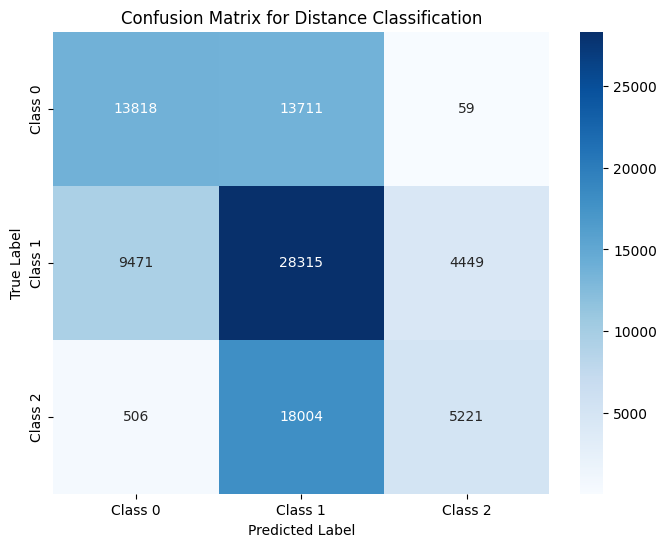

Confusion matrix saved to /content/drive/MyDrive/confusion_matrix.png


In [ ]:
def plot_confusion_matrix(model, loader, device, save_path="confusion_matrix.png"):

    model.eval()

    all_true_classes = []
    all_pred_classes = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device).unsqueeze(1)

            out = model(x)

            true_classes = [get_distance_class(t.item()) for t in y.squeeze()]
            pred_classes = [get_distance_class(p.item()) for p in out.squeeze()]

            all_true_classes.extend(true_classes)
            all_pred_classes.extend(pred_classes)

    # Convert to numpy arrays
    all_true_classes = np.array(all_true_classes)
    all_pred_classes = np.array(all_pred_classes)

    # Compute confusion matrix
    cm = confusion_matrix(all_true_classes, all_pred_classes, labels=[0, 1, 2])

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'Class {c}' for c in DISTANCE_BINS.keys()],
        yticklabels=[f'Class {c}' for c in DISTANCE_BINS.keys()]
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for Distance Classification')
    plt.savefig(save_path)
    plt.show()
    print(f"Confusion matrix saved to {save_path}")

# Call the function to plot and save the confusion matrix
plot_confusion_matrix(
    model,
    test_loader,
    device,
    save_path="/content/drive/MyDrive/confusion_matrix.png"
)


In [ ]:
def perturb_spectrogram(input_spectrogram, num_channels, num_mels, num_frames, perturbation_percentage=0.1):
    """
    Perturbs a given spectrogram by masking a random rectangular region with zeros.

    Args:
        input_spectrogram (torch.Tensor): The original spectrogram (channels, mels, frames).
        num_channels (int): Number of channels in the spectrogram.
        num_mels (int): Number of mel bins.
        num_frames (int): Number of time frames.
        perturbation_percentage (float): Percentage of the spectrogram to mask.

    Returns:
        torch.Tensor: The perturbed spectrogram.
    """
    perturbed_spec = input_spectrogram.clone() # Create a copy to perturb

    # Determine the size of the perturbation block
    mask_mels = int(num_mels * perturbation_percentage)
    mask_frames = int(num_frames * perturbation_percentage)

    if mask_mels == 0: mask_mels = 1
    if mask_frames == 0: mask_frames = 1

    # Randomly choose a starting point for the mask
    start_mel = random.randint(0, num_mels - mask_mels)
    start_frame = random.randint(0, num_frames - mask_frames)

    end_mel = start_mel + mask_mels
    end_frame = start_frame + mask_frames

    # Apply the mask across all channels
    perturbed_spec[:, start_mel:end_mel, start_frame:end_frame] = 0

    return perturbed_spec

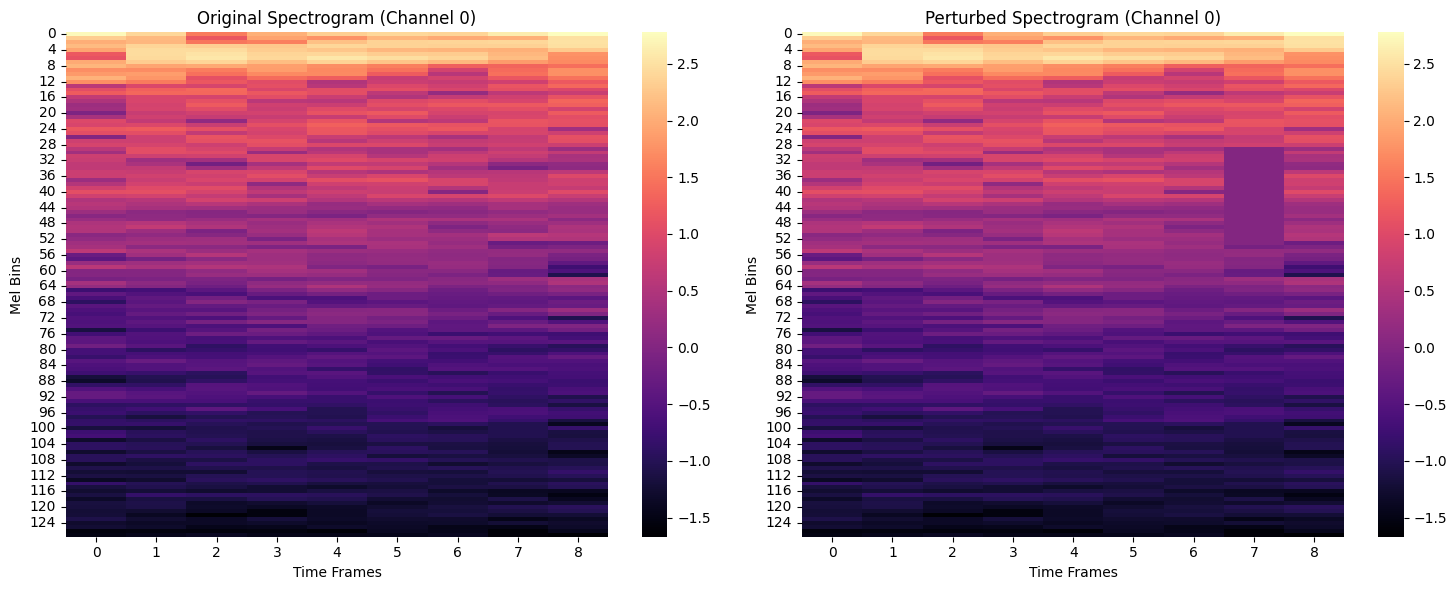

In [ ]:
# Get a sample spectrogram from the test_dataset
sample_idx = 0  # You can change this index to view different samples
sample_mel_specs, _ = test_dataset[sample_idx]

original_spectrogram_channel = sample_mel_specs[0].cpu().numpy()

# Get dimensions for perturbation function
num_channels, num_mels, num_frames = sample_mel_specs.shape

# Perturb the sample spectrogram
perturbed_mel_specs = perturb_spectrogram(
    sample_mel_specs,
    num_channels=num_channels,
    num_mels=num_mels,
    num_frames=num_frames,
    perturbation_percentage=0.2 # Increased percentage for clearer visualization
)

perturbed_spectrogram_channel = perturbed_mel_specs[0].cpu().numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(original_spectrogram_channel, ax=axes[0], cmap='magma', cbar=True)
axes[0].set_title('Original Spectrogram (Channel 0)')
axes[0].set_xlabel('Time Frames')
axes[0].set_ylabel('Mel Bins')

sns.heatmap(perturbed_spectrogram_channel, ax=axes[1], cmap='magma', cbar=True)
axes[1].set_title('Perturbed Spectrogram (Channel 0)')
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('Mel Bins')

plt.tight_layout()
plt.show()